In [22]:
import warnings

# Instalasi library yang diperlukan (-q untuk mode quiet agar output rapi)
!pip install pandas mlxtend openpyxl -q
!pip install streamlit seaborn matplotlib pandas mlxtend openpyxl -q

print("✅ Library berhasil diinstal!")
warnings.filterwarnings("ignore")



✅ Library berhasil diinstal!


# PENGEMBANGAN DECISION SUPPORT SYSTEM BERBASIS ALGORITMA APRIORI 
## UNTUK ANALISIS POLA PEMINATAN MAHASISWA

### 📋 BAB 1: BUSINESS UNDERSTANDING (PEMAHAMAN BISNIS)

#### 1.1 Latar Belakang Masalah
1.	Bagaimana mengidentifikasi pola keterkaitan antar mata kuliah pilihan berdasarkan data historis peminatan untuk mendukung perencanaan akademik program studi?
2.	Bagaimana menyajikan informasi pola peminatan dan memberikan rekomendasi kombinasi mata kuliah secara interaktif guna membantu mahasiswa dalam pengambilan keputusan akademik?


#### 1.2 Tujuan Bisnis
1.	Mengidentifikasi pola keterkaitan antar mata kuliah pilihan mahasiswa berdasarkan data historis peminatan menggunakan teknik Association Rule Mining guna menghasilkan aturan asosiasi yang dapat mendukung perencanaan akademik program studi.
2.	Menyajikan informasi pola peminatan dan memberikan rekomendasi kombinasi mata kuliah secara interaktif melalui Decision Support System (DSS) berbasis web guna membantu mahasiswa dan dosen wali dalam pengambilan keputusan akademik.


#### 1.3 Stakeholder yang Diuntungkan
| Stakeholder | Manfaat |
|-------------|---------|
| Mahasiswa Baru | Mendapat rekomendasi MK yang tepat |
| Dosen Wali | Dasar data untuk konsultasi |
| Kaprodi | Insight untuk perencanaan kurikulum |

#### 1.4 Kriteria Kesuksesan (Success Criteria)
- ✅ Menemukan minimal 10 aturan asosiasi dengan Lift > 1.2
- ✅ Confidence rekomendasi minimal 60%
- ✅ Sistem dapat memberikan rekomendasi dalam waktu < 1 detik

#### 1.5 Metodologi: CRISP-DM
Proyek ini menggunakan **CRISP-DM** yang terdiri dari 6 tahap:
1. Business Understanding
2. Data Understanding  
3. Data Preparation
4. Modeling
5. Evaluation
6. Deployment

In [23]:
import pandas as pd

print("[TAHAP 1 & 2] Business & Data Understanding")

try:
    df_raw = pd.read_excel('data_mahasiswa.xlsx', sheet_name='Data Mahasiswa', header=None)

    header_idx = df_raw[df_raw[0].astype(str).str.strip() == 'No'].index[0]

    df = pd.read_excel('data_mahasiswa.xlsx', sheet_name='Data Mahasiswa', header=header_idx)

    df = df[df['No'].astype(str).str.isdigit()].reset_index(drop=True)

    print(f"Data berhasil dimuat. Jumlah data mahasiswa valid: {len(df)} orang.")
    print("\n--- 5 Baris Pertama Data ---")
    display(df.head())
    df.info()

    print(df.dtypes)

except FileNotFoundError:
    print("❌ Error: File 'data_mahasiswa.xlsx' tidak ditemukan.")
    print("   Pastikan nama file persis 'data_mahasiswa.xlsx' (huruf kecil semua) dan sudah diunggah di folder kiri.")
except IndexError:
    print("❌ Error: Kolom 'No' tidak ditemukan di file Excel.")
    print("   Pastikan sheet bernama 'Data Mahasiswa' dan memiliki kolom 'No'.")
except Exception as e:
    print(f"❌ Terjadi kesalahan yang tidak terduga: {e}")

[TAHAP 1 & 2] Business & Data Understanding
Data berhasil dimuat. Jumlah data mahasiswa valid: 100 orang.

--- 5 Baris Pertama Data ---


,No,Nama,NIM,Data mining,Desain Grafis,Sistem Informasi Pendidikan,Teknologi IoT,Pengolahan Citra Digital,Pemrograman CMS,Realitas Virtual,Game Edukasi,Sistem Keamanan Jaringan
0,1,Ade,P03189001,✓,✗,✗,✓,✓,✓,✗,✗,✗
1,2,Arina,P03189002,✗,✗,✗,✓,✓,✓,✓,✗,✗
2,3,Dias,P03189003,✓,✗,✗,✗,✓,✓,✓,✗,✗
3,4,Bagas,P03189004,✗,✗,✗,✗,✓,✓,✓,✓,✓
4,5,Reyhan,P03189005,✓,✓,✗,✗,✓,✓,✗,✓,✗


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   No                           100 non-null    object
 1   Nama                         100 non-null    object
 2   NIM                          100 non-null    object
 3   Data mining                  100 non-null    object
 4   Desain Grafis                100 non-null    object
 5   Sistem Informasi Pendidikan  100 non-null    object
 6   Teknologi IoT                100 non-null    object
 7   Pengolahan Citra Digital     100 non-null    object
 8   Pemrograman CMS              100 non-null    object
 9   Realitas Virtual             100 non-null    object
 10  Game Edukasi                 100 non-null    object
 11  Sistem Keamanan Jaringan     100 non-null    object
dtypes: object(12)
memory usage: 9.5+ KB
No                             object
Nama               

In [24]:
print("[TAHAP 3] Data Preparation")

kolom_mk = [
    'Data mining', 'Desain Grafis', 'Sistem Informasi Pendidikan',
    'Teknologi IoT', 'Pengolahan Citra Digital', 'Pemrograman CMS',
    'Realitas Virtual', 'Game Edukasi', 'Sistem Keamanan Jaringan'
]

df_mk = df[kolom_mk].copy()

df_mk_bool = df_mk.replace({'✓': True, '✗': False})

print("Data berhasil diubah ke format Boolean (True/False).")
print("\n--- Contoh Data Setelah Preparasi ---")
display(df_mk_bool.head())

[TAHAP 3] Data Preparation
Data berhasil diubah ke format Boolean (True/False).

--- Contoh Data Setelah Preparasi ---


,Data mining,Desain Grafis,Sistem Informasi Pendidikan,Teknologi IoT,Pengolahan Citra Digital,Pemrograman CMS,Realitas Virtual,Game Edukasi,Sistem Keamanan Jaringan
0,True,False,False,True,True,True,False,False,False
1,False,False,False,True,True,True,True,False,False
2,True,False,False,False,True,True,True,False,False
3,False,False,False,False,True,True,True,True,True
4,True,True,False,False,True,True,False,True,False


TAHAP EKSPLORASI DATA & STATISTIK DESKRIPTIF

STATISTIK DESKRIPTIF DATA MAHASISWA
----------------------------------------------------------------------
Total Mahasiswa          : 100 orang
Total Mata Kuliah        : 9 mata kuliah

Statistik Jumlah MK per Mahasiswa:
  • Minimum              : 1 MK
  • Maksimum             : 8 MK
  • Rata-rata (Mean)     : 4.79 MK
  • Median               : 5 MK
  • Std Deviation        : 1.17 MK


POPULARITAS SETIAP MATA KULIAH
----------------------------------------------------------------------
 1. Pemrograman CMS                :  94 mahasiswa ( 94.0%) ███████████████████████████████████████████████
 2. Realitas Virtual               :  87 mahasiswa ( 87.0%) ███████████████████████████████████████████
 3. Pengolahan Citra Digital       :  68 mahasiswa ( 68.0%) ██████████████████████████████████
 4. Data mining                    :  64 mahasiswa ( 64.0%) ████████████████████████████████
 5. Game Edukasi                   :  62 mahasiswa ( 62.0%) ███

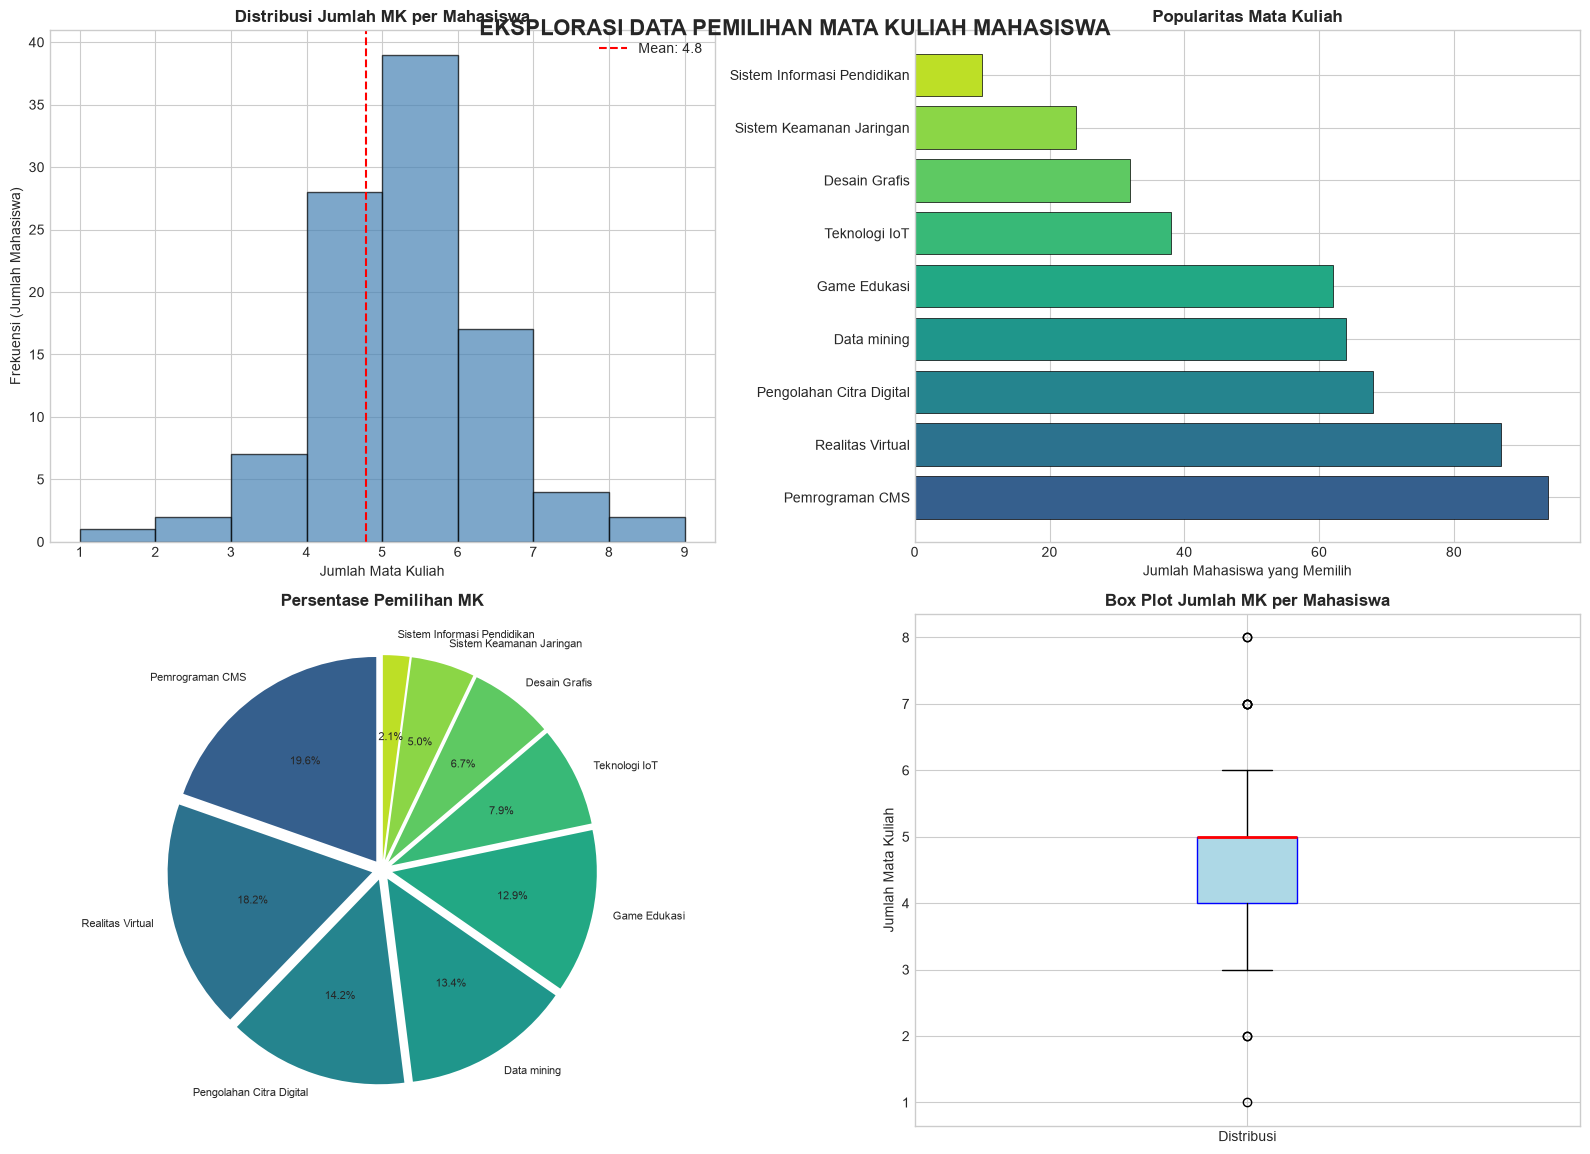


Visualisasi eksplorasi data berhasil dibuat!


In [25]:
print("="*70)
print("TAHAP EKSPLORASI DATA & STATISTIK DESKRIPTIF")
print("="*70)

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("\nSTATISTIK DESKRIPTIF DATA MAHASISWA")
print("-" * 70)

df['Jumlah_MK'] = df_mk_bool.sum(axis=1)

print(f"Total Mahasiswa          : {len(df)} orang")
print(f"Total Mata Kuliah        : {len(kolom_mk)} mata kuliah")
print(f"\nStatistik Jumlah MK per Mahasiswa:")
print(f"  • Minimum              : {df['Jumlah_MK'].min()} MK")
print(f"  • Maksimum             : {df['Jumlah_MK'].max()} MK")
print(f"  • Rata-rata (Mean)     : {df['Jumlah_MK'].mean():.2f} MK")
print(f"  • Median               : {df['Jumlah_MK'].median():.0f} MK")
print(f"  • Std Deviation        : {df['Jumlah_MK'].std():.2f} MK")

print("\n\nPOPULARITAS SETIAP MATA KULIAH")
print("-" * 70)

popularitas = df_mk_bool.sum().sort_values(ascending=False)
for i, (mk, count) in enumerate(popularitas.items(), 1):
    percentage = (count / len(df)) * 100
    bar = "█" * int(percentage / 2)
    print(f"{i:2}. {mk:30} : {count:3} mahasiswa ({percentage:5.1f}%) {bar}")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('EKSPLORASI DATA PEMILIHAN MATA KULIAH MAHASISWA', 
             fontsize=16, fontweight='bold', y=0.95)

axes[0, 0].hist(df['Jumlah_MK'], bins=range(1, 10), 
                edgecolor='black', color='steelblue', alpha=0.7)
axes[0, 0].set_title('Distribusi Jumlah MK per Mahasiswa', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Jumlah Mata Kuliah')
axes[0, 0].set_ylabel('Frekuensi (Jumlah Mahasiswa)')
axes[0, 0].axvline(df['Jumlah_MK'].mean(), color='red', linestyle='--', 
                   label=f'Mean: {df["Jumlah_MK"].mean():.1f}')
axes[0, 0].legend()

colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(popularitas)))
bars = axes[0, 1].barh(popularitas.index, popularitas.values, 
                        color=colors, edgecolor='black', linewidth=0.5)
axes[0, 1].set_title('Popularitas Mata Kuliah', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Jumlah Mahasiswa yang Memilih')

explode = [0.05] * len(popularitas)
axes[1, 0].pie(popularitas.values, labels=popularitas.index, 
               autopct='%1.1f%%', startangle=90, 
               colors=colors, explode=explode,
               textprops={'fontsize': 8})
axes[1, 0].set_title('Persentase Pemilihan MK', fontsize=12, fontweight='bold')

axes[1, 1].boxplot(df['Jumlah_MK'], vert=True, patch_artist=True,
                   boxprops=dict(facecolor='lightblue', color='blue'),
                   medianprops=dict(color='red', linewidth=2))
axes[1, 1].set_title('Box Plot Jumlah MK per Mahasiswa', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Jumlah Mata Kuliah')
axes[1, 1].set_xticks([1])
axes[1, 1].set_xticklabels(['Distribusi'])

plt.tight_layout()
plt.show()

print("\nVisualisasi eksplorasi data berhasil dibuat!")

[TAHAP 4] Modeling
TAHAP PARAMETER TUNING

EKSPERIMEN DENGAN BERBAGAI KOMBINASI PARAMETER
----------------------------------------------------------------------
Tujuan: Menemukan parameter optimal yang menghasilkan aturan
        berkualitas tinggi (Lift > 1.2, Confidence > 50%)


 Eksperimen 1: Support Rendah
   Support: 0.05 | Confidence: 0.5
  • Total Frequent Itemsets    : 189
  • Total Aturan Asosiasi      : 757
  • Aturan Berkualitas (Lift>1.2): 169
  • Rata-rata Lift             : 1.095
  • Rata-rata Confidence       : 0.717

 Eksperimen 2: Support Sedang (DEFAULT)
   Support: 0.1 | Confidence: 0.5
  • Total Frequent Itemsets    : 105
  • Total Aturan Asosiasi      : 380
  • Aturan Berkualitas (Lift>1.2): 37
  • Rata-rata Lift             : 1.026
  • Rata-rata Confidence       : 0.712

 Eksperimen 3: Support Tinggi
   Support: 0.15 | Confidence: 0.5
  • Total Frequent Itemsets    : 75
  • Total Aturan Asosiasi      : 239
  • Aturan Berkualitas (Lift>1.2): 7
  • Rata-rata Lift   

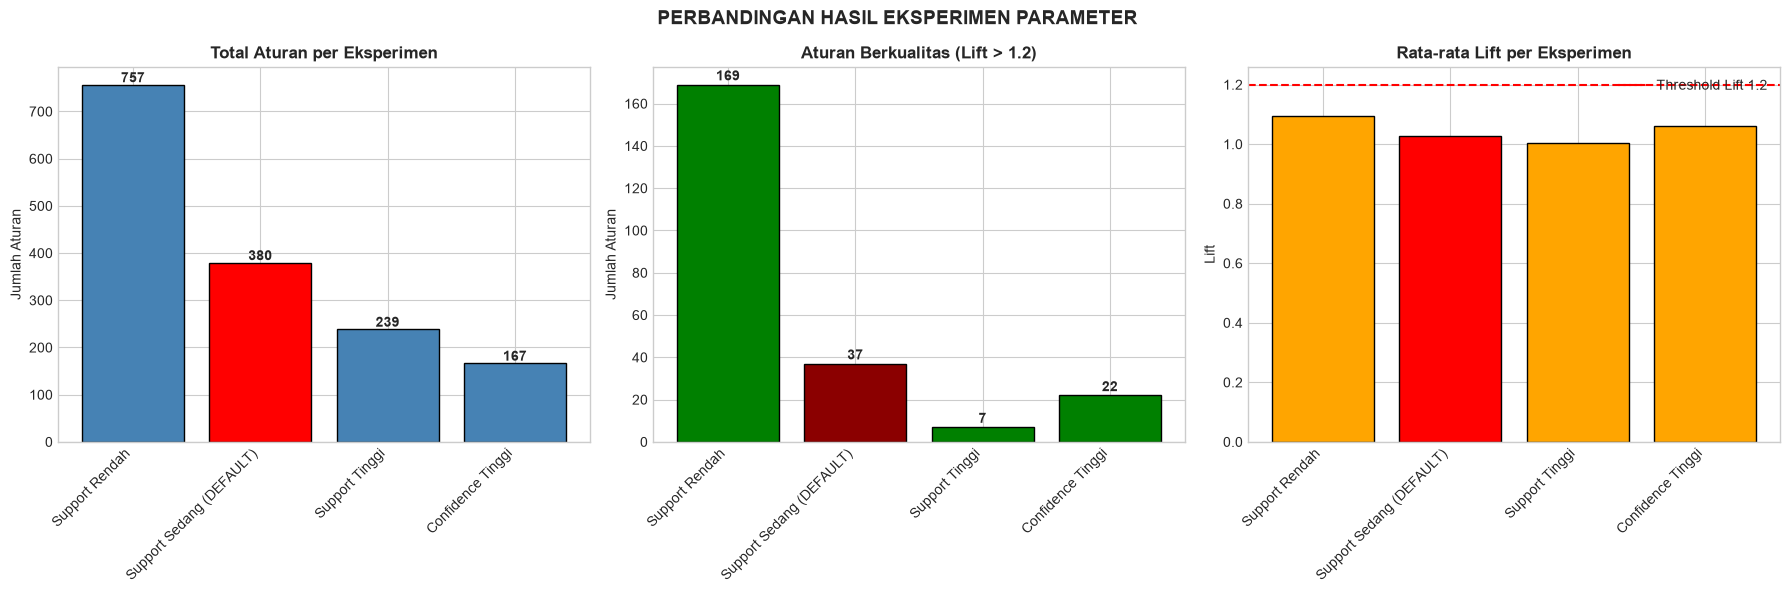



 JUSTIFIKASI PEMILIHAN PARAMETER OPTIMAL

ANALISIS HASIL EKSPERIMEN:

1. Eksperimen dengan Support terlalu rendah (0.05):
   ❌ Menghasilkan terlalu banyak aturan (noise)
   ❌ Banyak aturan yang tidak signifikan secara statistik

2. Eksperimen dengan Support terlalu tinggi (0.15):
   ❌ Aturan yang dihasilkan terlalu sedikit
   ❌ Kehilangan pola-pola menarik yang jarang muncul

3. Eksperimen dengan Confidence terlalu tinggi (0.70):
   ❌ Terlalu ketat, banyak pola valid terlewat

✅ KESIMPULAN: Parameter optimal adalah
   • Minimum Support    = 0.10 (10%)
   • Minimum Confidence = 0.50 (50%)

   Alasan:
   • Menyeimbangkan antara jumlah aturan dan kualitas
   • Menghasilkan aturan dengan Lift > 1.2 yang cukup
   • Confidence 50% masih dapat diterima untuk rekomendasi
   • Support 10% berarti pola muncul di minimal 10 mahasiswa

Ditemukan 105 kombinasi mata kuliah yang sering muncul.
Ditemukan 380 aturan asosiasi yang valid.


In [26]:
from mlxtend.frequent_patterns import apriori, association_rules

print("[TAHAP 4] Modeling")

print("="*70)
print("TAHAP PARAMETER TUNING")
print("="*70)

print("\nEKSPERIMEN DENGAN BERBAGAI KOMBINASI PARAMETER")
print("-" * 70)
print("Tujuan: Menemukan parameter optimal yang menghasilkan aturan")
print("        berkualitas tinggi (Lift > 1.2, Confidence > 50%)")
print()

parameter_combinations = [
    {'support': 0.05, 'confidence': 0.50, 'label': 'Eksperimen 1: Support Rendah'},
    {'support': 0.10, 'confidence': 0.50, 'label': 'Eksperimen 2: Support Sedang (DEFAULT)'},
    {'support': 0.15, 'confidence': 0.50, 'label': 'Eksperimen 3: Support Tinggi'},
    {'support': 0.10, 'confidence': 0.70, 'label': 'Eksperimen 4: Confidence Tinggi'},
]

results_summary = []

for exp in parameter_combinations:
    print(f"\n{'='*70}")
    print(f" {exp['label']}")
    print(f"   Support: {exp['support']} | Confidence: {exp['confidence']}")
    print(f"{'='*70}")
    
    freq_items = apriori(df_mk_bool, min_support=exp['support'], use_colnames=True)
    rules_exp = association_rules(freq_items, metric="confidence", min_threshold=exp['confidence'])
    
    rules_quality = rules_exp[rules_exp['lift'] > 1.2]
    
    print(f"  • Total Frequent Itemsets    : {len(freq_items)}")
    print(f"  • Total Aturan Asosiasi      : {len(rules_exp)}")
    print(f"  • Aturan Berkualitas (Lift>1.2): {len(rules_quality)}")
    
    if len(rules_exp) > 0:
        avg_lift = rules_exp['lift'].mean()
        avg_conf = rules_exp['confidence'].mean()
        print(f"  • Rata-rata Lift             : {avg_lift:.3f}")
        print(f"  • Rata-rata Confidence       : {avg_conf:.3f}")
    
    results_summary.append({
        'Eksperimen': exp['label'].split(': ')[1],
        'Support': exp['support'],
        'Confidence': exp['confidence'],
        'Total_Aturan': len(rules_exp),
        'Aturan_Berkualitas': len(rules_quality),
        'Avg_Lift': rules_exp['lift'].mean() if len(rules_exp) > 0 else 0,
    })

df_results = pd.DataFrame(results_summary)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(' PERBANDINGAN HASIL EKSPERIMEN PARAMETER', 
             fontsize=14, fontweight='bold')

colors = ['steelblue' if i != 1 else 'red' for i in range(len(df_results))]
axes[0].bar(df_results['Eksperimen'], df_results['Total_Aturan'], 
            color=colors, edgecolor='black')
axes[0].set_title('Total Aturan per Eksperimen', fontweight='bold')
axes[0].set_ylabel('Jumlah Aturan')
plt.setp(axes[0].get_xticklabels(), rotation=45, ha='right')
for i, v in enumerate(df_results['Total_Aturan']):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

colors2 = ['green' if i != 1 else 'darkred' for i in range(len(df_results))]
axes[1].bar(df_results['Eksperimen'], df_results['Aturan_Berkualitas'], 
            color=colors2, edgecolor='black')
axes[1].set_title('Aturan Berkualitas (Lift > 1.2)', fontweight='bold')
axes[1].set_ylabel('Jumlah Aturan')
plt.setp(axes[1].get_xticklabels(), rotation=45, ha='right')
for i, v in enumerate(df_results['Aturan_Berkualitas']):
    axes[1].text(i, v + 2, str(v), ha='center', fontweight='bold')

colors3 = ['orange' if i != 1 else 'red' for i in range(len(df_results))]
axes[2].bar(df_results['Eksperimen'], df_results['Avg_Lift'], 
            color=colors3, edgecolor='black')
axes[2].axhline(y=1.2, color='red', linestyle='--', label='Threshold Lift 1.2')
axes[2].set_title('Rata-rata Lift per Eksperimen', fontweight='bold')
axes[2].set_ylabel('Lift')
axes[2].legend()
plt.setp(axes[2].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

print("\n\n JUSTIFIKASI PEMILIHAN PARAMETER OPTIMAL")
print("="*70)
print("""
ANALISIS HASIL EKSPERIMEN:

1. Eksperimen dengan Support terlalu rendah (0.05):
   ❌ Menghasilkan terlalu banyak aturan (noise)
   ❌ Banyak aturan yang tidak signifikan secara statistik
   
2. Eksperimen dengan Support terlalu tinggi (0.15):
   ❌ Aturan yang dihasilkan terlalu sedikit
   ❌ Kehilangan pola-pola menarik yang jarang muncul
   
3. Eksperimen dengan Confidence terlalu tinggi (0.70):
   ❌ Terlalu ketat, banyak pola valid terlewat
   
✅ KESIMPULAN: Parameter optimal adalah
   • Minimum Support    = 0.10 (10%)
   • Minimum Confidence = 0.50 (50%)
   
   Alasan:
   • Menyeimbangkan antara jumlah aturan dan kualitas
   • Menghasilkan aturan dengan Lift > 1.2 yang cukup
   • Confidence 50% masih dapat diterima untuk rekomendasi
   • Support 10% berarti pola muncul di minimal 10 mahasiswa
""")

frequent_itemsets = apriori(df_mk_bool, min_support=0.10, use_colnames=True)
print(f"Ditemukan {len(frequent_itemsets)} kombinasi mata kuliah yang sering muncul.")

rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.5)
print(f"Ditemukan {len(rules)} aturan asosiasi yang valid.")

In [27]:
print("[TAHAP 5] Evaluation")

rules_sorted = rules.sort_values(by='lift', ascending=False).reset_index(drop=True)

kolom_tampilan = ['antecedents', 'consequents', 'support', 'confidence', 'lift']
print("\n--- 10 Aturan Asosiasi Terbaik (Lift Tertinggi) ---")
display(rules_sorted[kolom_tampilan].head(10))

print("\nPANDUAN MEMBACA HASIL:")
print("• antecedents : Mata kuliah yang diambil lebih dulu (JIKA).")
print("• consequents : Mata kuliah yang direkomendasikan (MAKA).")
print("• support     : Seberapa sering kombinasi ini muncul di seluruh data (misal 0.15 = 15%).")
print("• confidence  : Seberapa yakin (%) consequents akan diambil jika antecedents diambil.")
print("• lift        : Kekuatan hubungan. Lift > 1 berarti hubungan positif (saling menguatkan).")

print("\n\nVALIDASI MODEL")
print("="*70)

print("""
METODE VALIDASI YANG DIGUNAKAN:

1. Internal Validation (Metrik Evaluasi):
   • Support ≥ 0.10 (aturan muncul minimal di 10% transaksi)
   • Confidence ≥ 0.50 (keyakinan minimal 50%)
   • Lift > 1.0 (hubungan positif, bukan kebetulan)

2. Quality Threshold:
   • Aturan berkualitas: Lift > 1.2
   • Rekomendasi kuat: Confidence > 60%

3. Cross-Parameter Testing:
   • Menguji berbagai kombinasi parameter
   • Memilih setting yang menghasilkan aturan optimal
""")

valid_rules = rules_sorted[
    (rules_sorted['support'] >= 0.10) & 
    (rules_sorted['confidence'] >= 0.50) & 
    (rules_sorted['lift'] > 1.0)
]

quality_rules = rules_sorted[rules_sorted['lift'] > 1.2]

print(f"\nHASIL VALIDASI:")
print(f"  • Total aturan yang ditemukan: {len(rules_sorted)}")
print(f"  • Aturan valid (memenuhi threshold): {len(valid_rules)}")
print(f"  • Aturan berkualitas tinggi (Lift>1.2): {len(quality_rules)}")
print(f"  • Persentase validitas: {(len(valid_rules)/len(rules_sorted))*100:.1f}%")

if len(quality_rules) >= 10:
    print("\n MODEL DIVALIDASI: Ditemukan minimal 10 aturan berkualitas!")
else:
    print(f"\n MODEL PERLU IMPROVEMENT: Hanya {len(quality_rules)} aturan berkualitas")


[TAHAP 5] Evaluation

--- 10 Aturan Asosiasi Terbaik (Lift Tertinggi) ---


,antecedents,consequents,support,confidence,lift
0,"(Pengolahan Citra Digital, Realitas Virtual, D...","(Teknologi IoT, Pemrograman CMS)",0.10,0.526316,1.461988
1,"(Pengolahan Citra Digital, Teknologi IoT, Real...",(Data mining),0.10,0.909091,1.420455
2,"(Pengolahan Citra Digital, Teknologi IoT, Game...","(Realitas Virtual, Data mining)",0.10,0.769231,1.398601
3,"(Teknologi IoT, Game Edukasi, Pemrograman CMS)","(Pengolahan Citra Digital, Realitas Virtual, D...",0.10,0.500000,1.388889
4,"(Pengolahan Citra Digital, Realitas Virtual, D...",(Teknologi IoT),0.10,0.526316,1.385042
5,"(Pengolahan Citra Digital, Realitas Virtual, D...",(Teknologi IoT),0.10,0.526316,1.385042
6,"(Data mining, Desain Grafis)","(Game Edukasi, Pemrograman CMS)",0.13,0.812500,1.354167
7,"(Pemrograman CMS, Sistem Keamanan Jaringan)","(Realitas Virtual, Game Edukasi)",0.15,0.714286,1.347709
8,"(Pengolahan Citra Digital, Teknologi IoT, Real...","(Data mining, Pemrograman CMS)",0.10,0.833333,1.322751
9,"(Pengolahan Citra Digital, Teknologi IoT, Game...","(Realitas Virtual, Data mining, Pemrograman CMS)",0.10,0.714286,1.322751



PANDUAN MEMBACA HASIL:
• antecedents : Mata kuliah yang diambil lebih dulu (JIKA).
• consequents : Mata kuliah yang direkomendasikan (MAKA).
• support     : Seberapa sering kombinasi ini muncul di seluruh data (misal 0.15 = 15%).
• confidence  : Seberapa yakin (%) consequents akan diambil jika antecedents diambil.
• lift        : Kekuatan hubungan. Lift > 1 berarti hubungan positif (saling menguatkan).


VALIDASI MODEL

METODE VALIDASI YANG DIGUNAKAN:

1. Internal Validation (Metrik Evaluasi):
   • Support ≥ 0.10 (aturan muncul minimal di 10% transaksi)
   • Confidence ≥ 0.50 (keyakinan minimal 50%)
   • Lift > 1.0 (hubungan positif, bukan kebetulan)

2. Quality Threshold:
   • Aturan berkualitas: Lift > 1.2
   • Rekomendasi kuat: Confidence > 60%

3. Cross-Parameter Testing:
   • Menguji berbagai kombinasi parameter
   • Memilih setting yang menghasilkan aturan optimal


HASIL VALIDASI:
  • Total aturan yang ditemukan: 380
  • Aturan valid (memenuhi threshold): 207
  • Aturan berkual

In [28]:
print("="*70)
print("INTERPRETASI HASIL & INSIGHT BISNIS")
print("="*70)

top_rules = rules_sorted.head(10).copy()

print("\nANALISIS MENDALAM 10 ATURAN ASOSIASI TERBAIK")
print("="*70)

for i, row in top_rules.iterrows():
    antecedents = list(row['antecedents'])
    consequents = list(row['consequents'])
    support = row['support']
    confidence = row['confidence']
    lift = row['lift']
    
    print(f"\n{'─'*70}")
    print(f"ATURAN #{i+1}")
    print(f"{'─'*70}")
    print(f"  JIKA mahasiswa mengambil    : {', '.join(antecedents)}")
    print(f"  MAKA direkomendasikan juga  : {', '.join(consequents)}")
    print(f"  ─────────────────────────────────────────────────────────")
    print(f"  Support     : {support:.3f} ({support*100:.1f}% dari total mahasiswa)")
    print(f"  Confidence  : {confidence:.3f} ({confidence*100:.1f}% keyakinan)")
    print(f"  Lift        : {lift:.3f}", end=" ")
    
    if lift > 1.3:
        print("→ 🟢 HUBUNGAN SANGAT KUAT")
    elif lift > 1.1:
        print("→ 🟡 HUBUNGAN KUAT")
    else:
        print("→ 🟠 HUBUNGAN SEDANG")
    
    print(f"\n  💡 INTERPRETASI BISNIS:")
    print(f"     Dari 100 mahasiswa, sekitar {int(support*100)} mahasiswa mengambil")
    print(f"     kombinasi {', '.join(antecedents + consequents)}.")
    print(f"     Jika seorang mahasiswa sudah mengambil {', '.join(antecedents)},")
    print(f"     ada kemungkinan {confidence*100:.0f}% mereka juga akan mengambil")
    print(f"     {', '.join(consequents)}.")
    print(f"     Hubungan ini {lift:.2f}x lebih kuat dari pola acak.")

print("\n\n" + "="*70)
print("ANALISIS POLA KHUSUS YANG MENARIK")
print("="*70)

print("\nPOLA 1: Mata Kuliah yang Paling Sering Menjadi Pemicu Rekomendasi")
print("-" * 70)

antecedent_count = {}
for rule in rules_sorted.itertuples():
    for mk in rule.antecedents:
        antecedent_count[mk] = antecedent_count.get(mk, 0) + 1

sorted_antecedents = sorted(antecedent_count.items(), key=lambda x: x[1], reverse=True)
for i, (mk, count) in enumerate(sorted_antecedents[:5], 1):
    print(f"  {i}. {mk:35} → muncul di {count} aturan")

print("\nPOLA 2: Mata Kuliah yang Paling Sering Direkomendasikan")
print("-" * 70)

consequent_count = {}
for rule in rules_sorted.itertuples():
    for mk in rule.consequents:
        consequent_count[mk] = consequent_count.get(mk, 0) + 1

sorted_consequents = sorted(consequent_count.items(), key=lambda x: x[1], reverse=True)
for i, (mk, count) in enumerate(sorted_consequents[:5], 1):
    print(f"  {i}. {mk:35} → direkomendasikan di {count} aturan")

INTERPRETASI HASIL & INSIGHT BISNIS

ANALISIS MENDALAM 10 ATURAN ASOSIASI TERBAIK

──────────────────────────────────────────────────────────────────────
ATURAN #1
──────────────────────────────────────────────────────────────────────
  JIKA mahasiswa mengambil    : Pengolahan Citra Digital, Realitas Virtual, Data mining, Game Edukasi
  MAKA direkomendasikan juga  : Teknologi IoT, Pemrograman CMS
  ─────────────────────────────────────────────────────────
  Support     : 0.100 (10.0% dari total mahasiswa)
  Confidence  : 0.526 (52.6% keyakinan)
  Lift        : 1.462 → 🟢 HUBUNGAN SANGAT KUAT

  💡 INTERPRETASI BISNIS:
     Dari 100 mahasiswa, sekitar 10 mahasiswa mengambil
     kombinasi Pengolahan Citra Digital, Realitas Virtual, Data mining, Game Edukasi, Teknologi IoT, Pemrograman CMS.
     Jika seorang mahasiswa sudah mengambil Pengolahan Citra Digital, Realitas Virtual, Data mining, Game Edukasi,
     ada kemungkinan 53% mereka juga akan mengambil
     Teknologi IoT, Pemrograman CMS

In [29]:
print("[TAHAP 6] Deployment")

output_filename = 'hasil_aturan_asosiasi.xlsx'
rules_sorted.to_excel(output_filename, index=False)
print(f"Hasil aturan asosiasi berhasil disimpan sebagai '{output_filename}'.")
print("   (Klik ikon Folder di kiri, cari file tersebut, klik titik tiga, lalu Download)")

def beri_rekomendasi(mata_kuliah_diminati):
    aturan_terkait = rules_sorted[rules_sorted['antecedents'].apply(lambda x: mata_kuliah_diminati in x)]

    if aturan_terkait.empty:
        return f"⚠️ Tidak ditemukan pola asosiasi yang kuat untuk '{mata_kuliah_diminati}' dengan threshold saat ini."

    rek_best = aturan_terkait.iloc[0]
    mk_rekomendasi = list(rek_best['consequents'])
    confidence = rek_best['confidence'] * 100

    return f"Jika mahasiswa mengambil '{mata_kuliah_diminati}', sistem merekomendasikan juga mengambil: {', '.join(mk_rekomendasi)} (Keyakinan/Confidence: {confidence:.1f}%)"

print("\n--- CONTOH PENERAPAN DECISION SUPPORT SYSTEM ---")
print(beri_rekomendasi('Data mining'))
print(beri_rekomendasi('Pengolahan Citra Digital'))
print(beri_rekomendasi('Desain Grafis'))

[TAHAP 6] Deployment
Hasil aturan asosiasi berhasil disimpan sebagai 'hasil_aturan_asosiasi.xlsx'.
   (Klik ikon Folder di kiri, cari file tersebut, klik titik tiga, lalu Download)

--- CONTOH PENERAPAN DECISION SUPPORT SYSTEM ---
Jika mahasiswa mengambil 'Data mining', sistem merekomendasikan juga mengambil: Teknologi IoT, Pemrograman CMS (Keyakinan/Confidence: 52.6%)
Jika mahasiswa mengambil 'Pengolahan Citra Digital', sistem merekomendasikan juga mengambil: Teknologi IoT, Pemrograman CMS (Keyakinan/Confidence: 52.6%)
Jika mahasiswa mengambil 'Desain Grafis', sistem merekomendasikan juga mengambil: Game Edukasi, Pemrograman CMS (Keyakinan/Confidence: 81.2%)
